# Leak Location Benchmark

Objective

Study the effect of leak location on

• Pressure
• Flow
• Velocity
• Headloss

Leak size remains constant.

Only leak location changes.

Leak Locations

P1
P2
P3
P4
P5
P6
P7

Theory

Moving the leak changes the hydraulic resistance distribution.

Nodes closest to the leak experience the largest pressure drop.

This experiment is used for leak localization.

In [167]:
import wntr
import copy
import pandas as pd
import matplotlib.pyplot as plt

wn = wntr.network.WaterNetworkModel(
    "production_benchmark.inp"
)

In [168]:
pipes = [
    "P1",
    "P2",
    "P3",
    "P4",
    "P5",
    "P6",
    "P7"
]

LEAK_SIZE = 0.10
LEAK_POSITION = 0.5

In [169]:




benchmark = []

wn_leak = None      # Will store the P2 leak network

for pipe in pipes:

    print(f"Running Leak at {pipe}")

    wn_test = copy.deepcopy(wn)

    original = wn_test.get_link(pipe)

    start_node = original.start_node_name
    end_node = original.end_node_name

    length = original.length
    diameter = original.diameter
    roughness = original.roughness

    # Coordinates
    x1, y1 = wn_test.get_node(start_node).coordinates
    x2, y2 = wn_test.get_node(end_node).coordinates

    wn_test.remove_link(pipe)

    leak_node = f"Leak_{pipe}"

    wn_test.add_junction(
        leak_node,
        base_demand=LEAK_SIZE,
        elevation=12)

    x = x1 + LEAK_POSITION * (x2 - x1)
    y = y1 + LEAK_POSITION * (y2 - y1)

    wn_test.get_node(leak_node).coordinates = (x, y)

    wn_test.add_pipe(
        pipe + "A",
        start_node,
        leak_node,
        length=length * LEAK_POSITION,
        diameter=diameter,
        roughness=roughness
    )

    wn_test.add_pipe(
        pipe + "B",
        leak_node,
        end_node,
        length=length * (1 - LEAK_POSITION),
        diameter=diameter,
        roughness=roughness
    )

    # Save P2 leak network for visualization
    if pipe == "P2":
        wn_leak = copy.deepcopy(wn_test)

    sim = wntr.sim.EpanetSimulator(wn_test)

    result = sim.run_sim()

    pressure = result.node["pressure"].iloc[-1]
    flow = result.link["flowrate"].iloc[-1]
    velocity = result.link["velocity"].iloc[-1]
    headloss = result.link["headloss"].iloc[-1]

    row = {
        "Leak_Location": pipe,
        "Leak_Size": LEAK_SIZE,
        "Leak_Position": LEAK_POSITION
    }

    # Pressure
    for node in pressure.index:

        if node.startswith("Leak_"):
            continue

        row[f"Pressure_{node}"] = pressure[node]

    # Flow
    for p in pipes:

        if p == pipe:
            row[f"Flow_{p}"] = (
                flow[pipe + "A"] +
                flow[pipe + "B"]
            ) / 2
        else:
            row[f"Flow_{p}"] = flow[p]

    # Velocity
    for p in pipes:

        if p == pipe:
            row[f"Velocity_{p}"] = (
                velocity[pipe + "A"] +
                velocity[pipe + "B"]
            ) / 2
        else:
            row[f"Velocity_{p}"] = velocity[p]

    # Headloss
    for p in pipes:

        if p == pipe:
            row[f"Headloss_{p}"] = (
                headloss[pipe + "A"] +
                headloss[pipe + "B"]
            )
        else:
            row[f"Headloss_{p}"] = headloss[p]

    benchmark.append(row)

benchmark_df = pd.DataFrame(benchmark)

benchmark_df

Running Leak at P1
Running Leak at P2
Running Leak at P3
Running Leak at P4
Running Leak at P5
Running Leak at P6
Running Leak at P7


,Leak_Location,Leak_Size,Leak_Position,Pressure_J1,Pressure_J2,Pressure_J3,Pressure_J4,Pressure_Customer_A,Pressure_Customer_B,Pressure_Customer_C,...,Velocity_P5,Velocity_P6,Velocity_P7,Headloss_P1,Headloss_P2,Headloss_P3,Headloss_P4,Headloss_P5,Headloss_P6,Headloss_P7
0,P1,0.1,0.5,101.285080,95.049416,92.410225,72.935860,82.214462,80.656082,54.403812,...,1.510352,1.522782,2.013802,0.017430,0.003530,0.004844,0.016474,0.009670,0.007322,0.016474
1,P2,0.1,0.5,100.049461,92.730019,91.174599,71.700249,79.895073,78.336685,53.168194,...,1.510352,1.522782,2.013802,0.009951,0.008866,0.004844,0.016474,0.009670,0.007322,0.016474
2,P3,0.1,0.5,100.049461,93.813797,89.006721,69.532356,80.978844,79.420471,51.000309,...,1.510352,1.522782,2.013802,0.009951,0.003530,0.015107,0.016474,0.009670,0.007322,0.016474
3,P4,0.1,0.5,100.049461,93.813797,86.838821,58.147465,80.978844,79.420471,39.615414,...,1.510352,1.522782,2.013802,0.009951,0.003530,0.010263,0.051383,0.009670,0.007322,0.016474
4,P5,0.1,0.5,100.049461,91.646233,91.174599,71.700249,75.002525,77.252907,53.168194,...,2.013802,1.522782,2.013802,0.009951,0.005336,0.004844,0.016474,0.034575,0.007322,0.016474
5,P6,0.1,0.5,100.049461,91.646233,91.174599,71.700249,78.811287,75.353256,53.168194,...,1.510352,1.827339,2.013802,0.009951,0.005336,0.004844,0.016474,0.009670,0.020977,0.016474
6,P7,0.1,0.5,100.049461,93.813797,86.838821,48.930458,80.978844,79.420471,23.946508,...,1.510352,1.522782,2.517252,0.009951,0.003530,0.010263,0.034908,0.009670,0.007322,0.051383


C:\Users\Jatin\AppData\Local\Temp\ipykernel_27880\1748392403.py:4: DeprecationWarning: wntr.network.WaterNetworkModel.get_graph is deprecated, use wntr.network.WaterNetworkModel.to_graph instead
  G = wn_leak.get_graph()


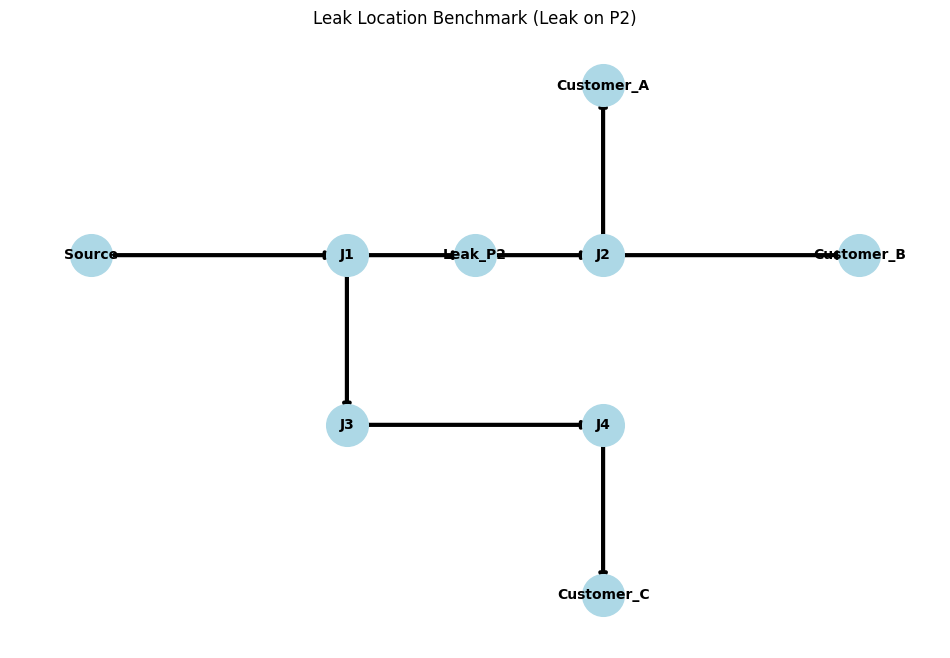

In [170]:

import networkx as nx
import matplotlib.pyplot as plt

G = wn_leak.get_graph()

pos = {}

for node_name in wn_leak.node_name_list:
    pos[node_name] = wn_leak.get_node(node_name).coordinates

plt.figure(figsize=(12,8))

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=900,
    node_color="lightblue"
)

nx.draw_networkx_edges(
    G,
    pos,
    width=3
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight="bold"
)

plt.title("Leak Location Benchmark (Leak on P2)")

plt.axis("off")

plt.show()

In [171]:
benchmark_df.to_csv(
    "Leak_Location_Benchmark.csv",
    index=False
)

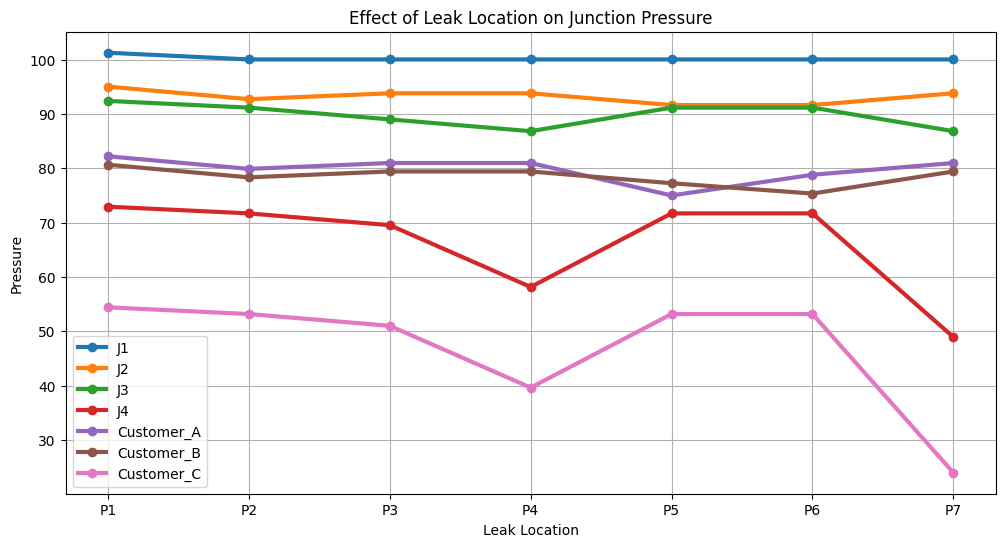

In [172]:
pressure_nodes = [

    "Pressure_J1",
    "Pressure_J2",
    "Pressure_J3",
    "Pressure_J4",
    "Pressure_Customer_A",
    "Pressure_Customer_B",
    "Pressure_Customer_C"

]

plt.figure(figsize=(12,6))

for node in pressure_nodes:

    plt.plot(

        benchmark_df["Leak_Location"],

        benchmark_df[node],

        marker="o",

        linewidth=3,

        label=node.replace("Pressure_","")

    )

plt.grid(True)

plt.xlabel("Leak Location")

plt.ylabel("Pressure")

plt.title("Effect of Leak Location on Junction Pressure")

plt.legend()

plt.show()

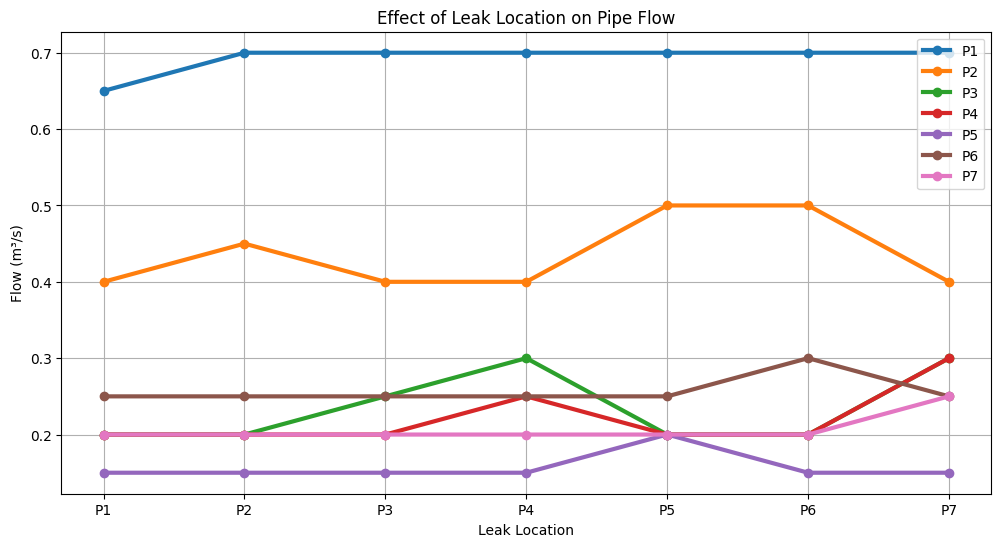

In [ ]:
plt.figure(figsize=(12,6))

for pipe in pipes:

    plt.plot(

        benchmark_df["Leak_Location"],

        benchmark_df[f"Flow_{pipe}"],

        marker="o",

        linewidth=3,

        label=pipe

    )

plt.grid(True)

plt.xlabel("Leak Location")

plt.ylabel("Flow (m^3/s)")

plt.title("Effect of Leak Location on Pipe Flow")

plt.legend()

plt.show()

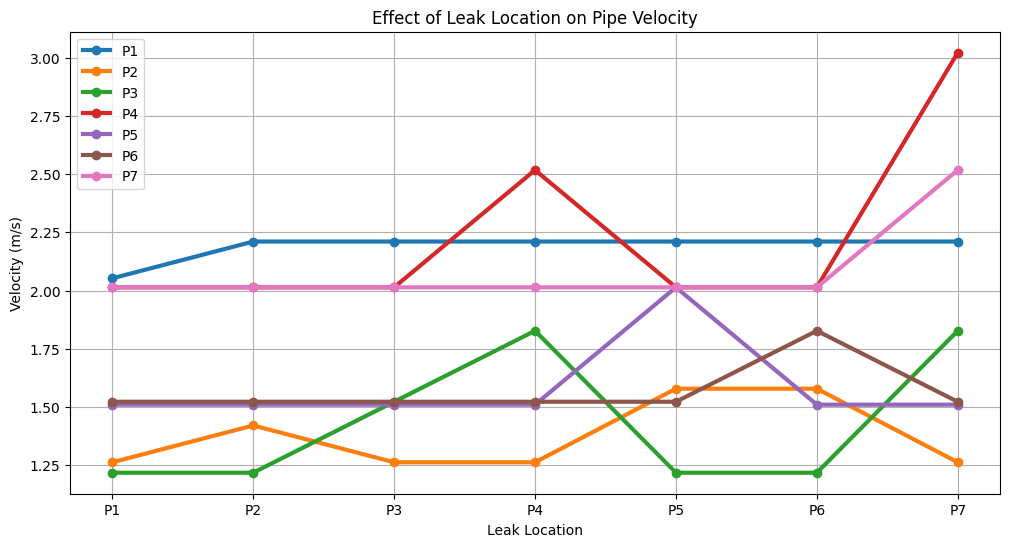

In [174]:
plt.figure(figsize=(12,6))

for pipe in pipes:

    plt.plot(

        benchmark_df["Leak_Location"],

        benchmark_df[f"Velocity_{pipe}"],

        marker="o",

        linewidth=3,

        label=pipe

    )

plt.grid(True)

plt.xlabel("Leak Location")

plt.ylabel("Velocity (m/s)")

plt.title("Effect of Leak Location on Pipe Velocity")

plt.legend()

plt.show()

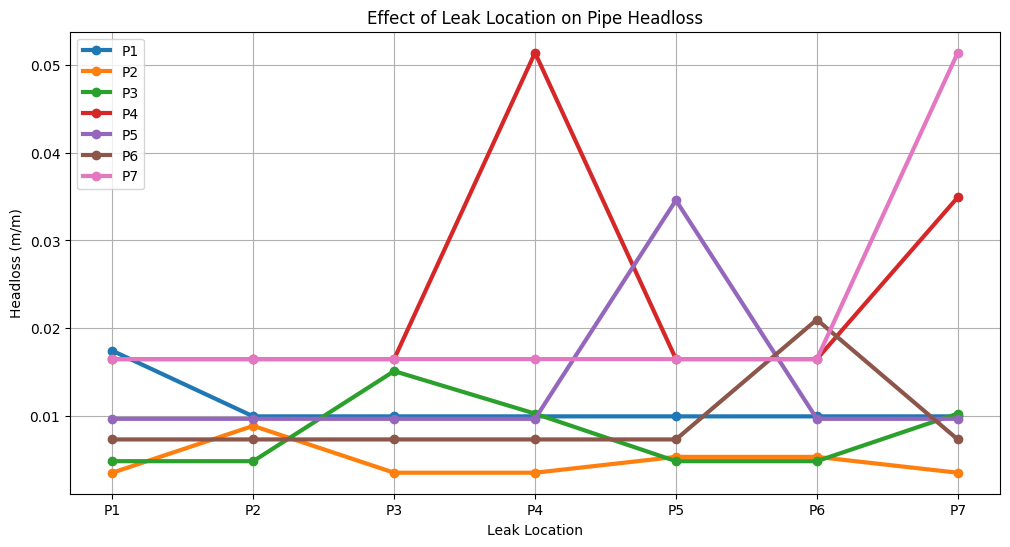

In [175]:
plt.figure(figsize=(12,6))

for pipe in pipes:

    plt.plot(

        benchmark_df["Leak_Location"],

        benchmark_df[f"Headloss_{pipe}"],

        marker="o",

        linewidth=3,

        label=pipe

    )

plt.grid(True)

plt.xlabel("Leak Location")

plt.ylabel("Headloss (m/m)")

plt.title("Effect of Leak Location on Pipe Headloss")

plt.legend()

plt.show()

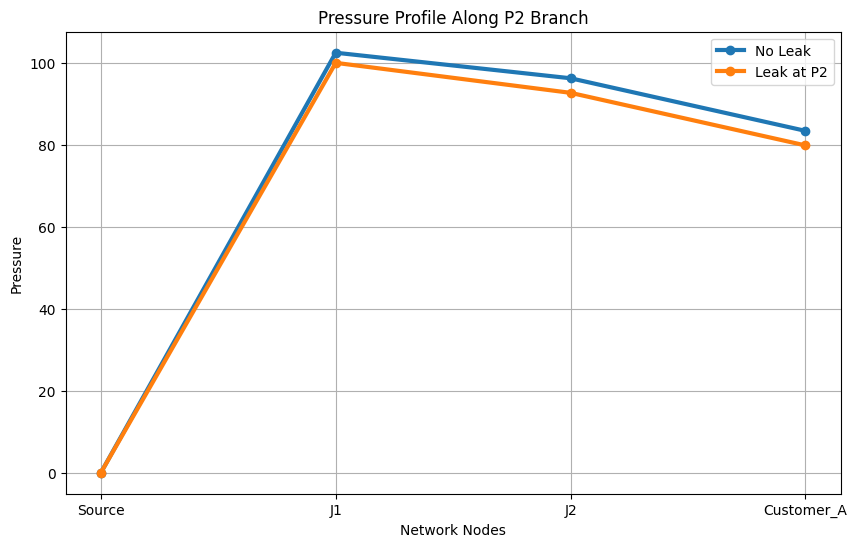

In [ ]:
baseline = wntr.sim.EpanetSimulator(wn).run_sim()

base = baseline.node["pressure"].iloc[-1]

p2 = benchmark_df[
    benchmark_df["Leak_Location"]=="P2"
].iloc[0]

nodes = [

    "Source",
    "J1",
    "J2",
    "Customer_A"

]

baseline_pressure = [

    base["Source"],
    base["J1"],
    base["J2"],
    base["Customer_A"]

]
W
leak_pressure = [

    p2["Pressure_Source"],
    p2["Pressure_J1"],
    p2["Pressure_J2"],
    p2["Pressure_Customer_A"]

]

plt.figure(figsize=(10,6))

plt.plot(

    nodes,

    baseline_pressure,

    marker="o",

    linewidth=3,

    label="No Leak"

)

plt.plot(

    nodes,

    leak_pressure,

    marker="o",

    linewidth=3,

    label="Leak at P2"

)

plt.grid(True)

plt.xlabel("Network Nodes")

plt.ylabel("Pressure")

plt.title("Pressure Profile Along P2 Branch")

plt.legend()

plt.show()